In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from lmfit.models import VoigtModel, ConstantModel

In [2]:
# collected data
BG = ("/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators"
      "/Bulk_crystal/10mK/02142025/LASEROFF.csv")
DATA_START = ("/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators"
              "/Bulk_crystal/10mK/01022025/PREINIT2.csv")
DATA_INIT_1 = ("/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators"
               "/Bulk_crystal/10mK/02142025/POSTINIT.csv")
DATA_INIT_2 = ("/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators"
               "/Bulk_crystal/10mK/02142025/POSTINIT2.csv")
FREQ_START = (194808.612, 194817.357)
FREQ_INIT_1 = (194810.024, 194818.577)
FREQ_INIT_2 = (194809.545, 194818.112)
AOM_OFFSET = 0.680  # unit: GHz

In [3]:
color_1 = 'coral'
color_2 = 'coral'
ref_freq = 194808

# fitting params
fit_start = 5.6
fit_end = 6.1

fit_start_polarize = 4
fit_end_polarize = 5.1

In [4]:
# REFERENCE DATA
df_laser_off = pd.read_csv(BG, header=10, skiprows=[11])
off_level = np.mean(df_laser_off['CH2'].astype(float).to_numpy())


# BEFORE PUMPING
df_before = pd.read_csv(DATA_START, header=10, skiprows=[11])

ramp = df_before['CH1'].astype(float).to_numpy()
transmission_before = df_before['CH2'].astype(float).to_numpy()
transmission_before -= off_level
print(off_level)

id_min = np.argmin(ramp)
id_max = np.argmax(ramp)
ramp = ramp[id_min:id_max]
transmission_before = transmission_before[id_min:id_max]

# convert to optical depth
bg = max(transmission_before)
od_before = np.log(bg / transmission_before)

# convert time to frequency
freq_before = np.linspace(FREQ_START[0]-ref_freq, FREQ_START[1]-ref_freq, id_max - id_min)  # unit: GHz
freq_before += AOM_OFFSET


# AFTER PUMPING (1)
df_after_1 = pd.read_csv(DATA_INIT_1, header=10, skiprows=[11])

ramp = df_after_1['CH1'].astype(float).to_numpy()
transmission_1 = df_after_1['CH2'].astype(float).to_numpy()
print(min(transmission_1))
transmission_1 -= off_level
print(min(transmission_1))

id_min = np.argmin(ramp)
id_max = np.argmax(ramp)
ramp = ramp[id_min:id_max]
transmission_1 = transmission_1[id_min:id_max]

# convert to optical depth
bg = max(transmission_1)
od_1 = np.log(bg / transmission_1)

# convert time to frequency
freq_init_1 = np.linspace(FREQ_INIT_1[0]-ref_freq, FREQ_INIT_1[1]-ref_freq, id_max - id_min)  # unit: GHz
freq_init_1 += AOM_OFFSET


# AFTER PUMPING (2)
df_after_2 = pd.read_csv(DATA_INIT_2, header=10, skiprows=[11])

ramp = df_after_2['CH1'].astype(float).to_numpy()
transmission_2 = df_after_2['CH2'].astype(float).to_numpy()
print(min(transmission_2))
transmission_2 -= off_level
print(min(transmission_2))

id_min = np.argmin(ramp)
id_max = np.argmax(ramp)
ramp = ramp[id_min:id_max]
transmission_2 = transmission_2[id_min:id_max]

# convert to optical depth
bg = max(transmission_2)
od_2 = np.log(bg / transmission_2)

# convert time to frequency
freq_init_2 = np.linspace(FREQ_INIT_2[0]-ref_freq, FREQ_INIT_2[1]-ref_freq, id_max - id_min)  # unit: GHz
freq_init_2 += AOM_OFFSET

-0.04228344565714286
-0.06000003
-0.017716584342857146
-0.05200002
-0.009716574342857144


/var/folders/9s/1vly09jx3z36sfxgrw8bfrf80000gn/T/ipykernel_61003/1821201429.py:44: RuntimeWarning: invalid value encountered in log
  od_1 = np.log(bg / transmission_1)
/var/folders/9s/1vly09jx3z36sfxgrw8bfrf80000gn/T/ipykernel_61003/1821201429.py:67: RuntimeWarning: invalid value encountered in log
  od_2 = np.log(bg / transmission_2)


In [5]:
# do fitting
freq_bounds = np.logical_and(freq_init_2 > fit_start, freq_init_2 < fit_end)
real_bounds = np.logical_and(freq_bounds, ~np.isnan(od_2))
idx_to_fit = np.where(real_bounds)[0]
model = VoigtModel() + ConstantModel()
res = model.fit(od_2[idx_to_fit], x=freq_init_2[idx_to_fit],
                center=5.75, sigma=0.25, c=0.1)
print(res.fit_report())
print(f"Center frequency: {ref_freq + res.params['center'].value}")

[[Model]]
    (Model(voigt) + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 44
    # data points      = 279
    # variables        = 4
    chi-square         = 24.2097797
    reduced chi-square = 0.08803556
    Akaike info crit   = -674.002976
    Bayesian info crit = -659.478128
    R-squared          = 0.95778696
[[Variables]]
    amplitude:  1.12531531 +/- 0.02802317 (2.49%) (init = 1)
    center:     5.81431478 +/- 8.5877e-04 (0.01%) (init = 5.75)
    sigma:      0.05081578 +/- 0.00106946 (2.10%) (init = 0.25)
    c:          0.09149500 +/- 0.04635628 (50.67%) (init = 0.1)
    gamma:      0.05081578 +/- 0.00106946 (2.10%) == 'sigma'
    fwhm:       0.18300240 +/- 0.00385143 (2.10%) == '1.0692*gamma+sqrt(0.8664*gamma**2+5.545083*sigma**2)'
    height:     4.62186628 +/- 0.05854943 (1.27%) == '(amplitude/(max(1e-15, sigma*sqrt(2*pi))))*real(wofz((1j*gamma)/(max(1e-15, sigma*sqrt(2)))))'
[[Correlations]] (unreported correlations are < 0.

## Population Fitting

To fit the population, we examine the $\Delta m = -1$ manifold of the post-initialization optical spectrum. We construct the relative frequencies of the optical transitions to be identical to that in the literature, and allow the center frequency to be a free parameter (as determined by the exact magnetic field).

First, we calculate the optical detuning for each $\Delta m = -1$ peak relative to the center frequency.

In [57]:
mw_transitions_g = np.array([994.7, 943, 898, 862, 831, 810, 796]) / 1e3  # unit: GHz
mw_transitions_e = np.array([994, 972, 953, 935, 918, 903, 889]) / 1e3  # unit: GHz

mw_energy_g = np.zeros(8)
mw_energy_g[1:] = np.cumsum(mw_transitions_g)
mw_energy_e = np.zeros(8)
mw_energy_e[1:] = np.cumsum(mw_transitions_e)
optical_detunings_neg1 = np.zeros(7)

for i in range(7):
    optical_detunings_neg1[i] = mw_energy_e[i] - mw_energy_g[i+1]

relative_optical_detunints_neg1 = optical_detunings_neg1 - min(optical_detunings_neg1)
print(optical_detunings_neg1)
print(relative_optical_detunints_neg1)
print(np.diff(relative_optical_detunints_neg1))

[-0.9947 -0.9437 -0.8697 -0.7787 -0.6747 -0.5667 -0.4597]
[0.    0.051 0.125 0.216 0.32  0.428 0.535]
[0.051 0.074 0.091 0.104 0.108 0.107]


We also denote the oscillator strength for each transition

In [140]:
oscillator_strengths = np.array([25, 21, 17, 14, 10, 6.3, 2.5])

Here, we do an initial plot and fit of the transition assuming 100% polarization to get a rough idea of the guess parameters for the fit.

In [62]:
idx_to_fit_polarize = np.logical_and(freq_init_2 > fit_start_polarize, freq_init_2 < fit_end_polarize)
idx_to_fit_polarize = np.where(idx_to_fit_polarize)[0]

x_data_polarize = freq_init_2[idx_to_fit_polarize]
y_data_polarize = od_2[idx_to_fit_polarize]

In [77]:
model_polarize_test = ConstantModel() + VoigtModel()
res_polarize_test = model_polarize_test.fit(y_data_polarize, x=x_data_polarize,
                                            c=0.1, center=4.9, sigma=0.15, amplitude=0.075)
print(res_polarize_test.fit_report())

[[Model]]
    (Model(constant) + Model(voigt))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 41
    # data points      = 644
    # variables        = 4
    chi-square         = 0.09061854
    reduced chi-square = 1.4159e-04
    Akaike info crit   = -5703.50408
    Bayesian info crit = -5685.63329
    R-squared          = 0.92522068
[[Variables]]
    c:          0.08575931 +/- 7.3600e-04 (0.86%) (init = 0.1)
    amplitude:  0.04607743 +/- 8.3219e-04 (1.81%) (init = 0.075)
    center:     4.86467062 +/- 0.00152252 (0.03%) (init = 4.9)
    sigma:      0.07553699 +/- 0.00137123 (1.82%) (init = 0.15)
    gamma:      0.07553699 +/- 0.00137123 (1.82%) == 'sigma'
    fwhm:       0.27203064 +/- 0.00493820 (1.82%) == '1.0692*gamma+sqrt(0.8664*gamma**2+5.545083*sigma**2)'
    height:     0.12731230 +/- 0.00152047 (1.19%) == '(amplitude/(max(1e-15, sigma*sqrt(2*pi))))*real(wofz((1j*gamma)/(max(1e-15, sigma*sqrt(2)))))'
[[Correlations]] (unreported correlations are < 

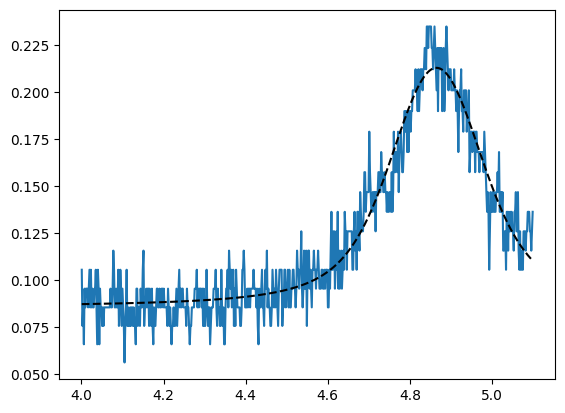

In [79]:
plt.plot(x_data_polarize, y_data_polarize)
plt.plot(x_data_polarize, res_polarize_test.best_fit, ls='--', color='k',)

Next, construct the model using `lmfit` and constrain the relative spacing of each peak.

In [112]:
model_polarize = ConstantModel()
for i in range(len(relative_optical_detunints_neg1)):
    prefix = f'p{i}_'
    model_polarize += VoigtModel(prefix=prefix)

# make params and constrain
params = model.make_params()
free_center_param = 'p0_center'
sigma_param = 'p0_sigma'

# add common guesses
center_guess = res_polarize_test.params['center'].value - relative_optical_detunints_neg1[-1]
params.add(free_center_param, value=center_guess,
           min=center_guess-0.05, max=center_guess+0.05)
params.add(free_sigma_param, value=res_polarize_test.params['sigma'].value, min=0, max=0.1)
# params.add(sigma_param, value=res.params['sigma'].value, vary=False)
params.add('c', value=res_polarize_test.params['c'].value, min=0, max=0.1)

for i, detuning in enumerate(relative_optical_detunints_neg1):
    prefix = f'p{i}_'

    # constrain later peaks to have fixed separation and width
    if i > 0:
        expr_center = free_center_param + '+' + str(detuning)
        params.add(prefix+'center', expr=expr_center)
        params.add(prefix+'sigma', expr=free_sigma_param)

    # give a guess of amplitude for each peak
    if i == len(relative_optical_detunints_neg1) - 1:  # guess higher amplitude for the last peak
        params.add(prefix+'amplitude', value=res_polarize_test.params['amplitude'].value, min=0, max=0.15)
    else:
        params.add(prefix+'amplitude', value=0.001, min=0, max=0.15)

print(params.pretty_print())

Name             Value      Min      Max   Stderr     Vary     Expr Brute_Step
c              0.08576        0      0.1     None     True     None     None
p0_amplitude     0.001        0     0.15     None     True     None     None
p0_center         4.33     4.28     4.38     None     True     None     None
p0_fwhm            nan     -inf      inf     None    False 1.0692*p0_gamma+sqrt(0.8664*p0_gamma**2+5.545083*p0_sigma**2)     None
p0_gamma       0.07554     -inf      inf     None    False p0_sigma     None
p0_height     0.002763     -inf      inf     None    False (p0_amplitude/(max(1e-15, p0_sigma*sqrt(2*pi))))*real(wofz((1j*p0_gamma)/(max(1e-15, p0_sigma*sqrt(2)))))     None
p0_sigma       0.07554        0      0.1     None     True     None     None
p1_amplitude     0.001        0     0.15     None     True     None     None
p1_center        4.381     -inf      inf     None    False p0_center+0.051000000000000045     None
p1_fwhm            nan     -inf      inf     None    Fal

/Users/alexkolar/Desktop/Lab/lab-plotting/venv/lib/python3.12/site-packages/asteval/astutils.py:245: RuntimeWarning: invalid value encountered in scalar add
  return arg1 + arg2


Finally, do the fitting

In [113]:
res_polarize = model_polarize.fit(y_data_polarize, x=x_data_polarize, params=params)
print(res_polarize.fit_report())

[[Model]]
    (((((((Model(constant) + Model(voigt, prefix='p0_')) + Model(voigt, prefix='p1_')) + Model(voigt, prefix='p2_')) + Model(voigt, prefix='p3_')) + Model(voigt, prefix='p4_')) + Model(voigt, prefix='p5_')) + Model(voigt, prefix='p6_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 254
    # data points      = 644
    # variables        = 10
    chi-square         = 0.08859738
    reduced chi-square = 1.3974e-04
    Akaike info crit   = -5706.03050
    Bayesian info crit = -5661.35351
    R-squared          = 0.92688856
[[Variables]]
    c:             0.08499560 +/- 0.00156138 (1.84%) (init = 0.08575931)
    p0_amplitude:  5.8971e-13 +/- 1.2770e-04 (21654209670.28%) (init = 0.001)
    p0_center:     4.33534526 +/- 0.00892184 (0.21%) (init = 4.329671)
    p0_sigma:      0.07058901 +/- 0.00354061 (5.02%) (init = 0.07553699)
    p1_amplitude:  2.3136e-12 +/- 10.7500871 (464642732198004.31%) (init = 0.001)
    p1_center:     4.38634526 +/- 0.008921

In [156]:
center_freqs = np.zeros(len(relative_optical_detunints_neg1))

for i in range(len(relative_optical_detunints_neg1)):
    center_freqs[i] = res_polarize.params[f'p{i}_center'].value

print(center_freqs)

[4.33534526 4.38634526 4.46034526 4.55134526 4.65534526 4.76334526
 4.87034526]


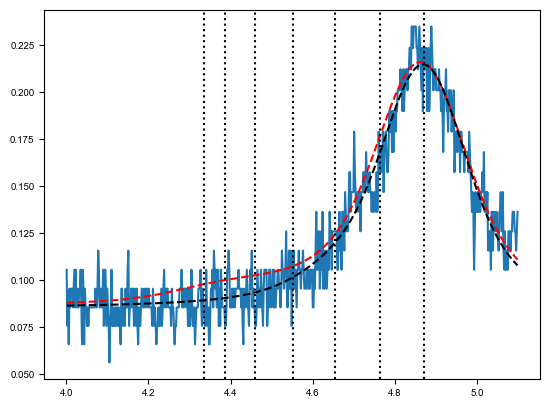

In [157]:
plt.plot(x_data_polarize, y_data_polarize)
plt.plot(x_data_polarize, res_polarize.init_fit, ls='--', color='r')
plt.plot(x_data_polarize, res_polarize.best_fit, ls='--', color='k')
for center_freq in center_freqs:
    plt.axvline(x=center_freq, ls=':', color='k')

Extract the heights of each transition and the relative populations

In [158]:
all_heights = np.zeros(len(relative_optical_detunints_neg1))

for i in range(len(relative_optical_detunints_neg1)):
    prefix = f'p{i}_'
    height = res_polarize.params[prefix+'height'].value
    all_heights[i] = height

all_heights_oscillator_corrected = all_heights / oscillator_strengths
total_height = np.sum(all_heights_oscillator_corrected)
relative_populations = all_heights_oscillator_corrected / total_height

# print(all_heights)
# print(all_heights_oscillator_corrected)
# print(relative_populations)
print(f'm = +7/2 estimated relative population: {relative_populations[-1]*100:.3f}%')

m = +7/2 estimated relative population: 98.175%


## Final Plotting

In [168]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 7})
figsize = (6, 3)  # inches
dpi = 300

# colors
color_memory = '#d95f02'
color_memory_2 = 'darkgray'

# figure layout
horizontal_ratios = (4, 2)
vertical_padding = 0.02
horizontal_padding = 0.02

xlim_inset = (fit_start_polarize, fit_end_polarize)
ylim_inset = (0, 0.3)

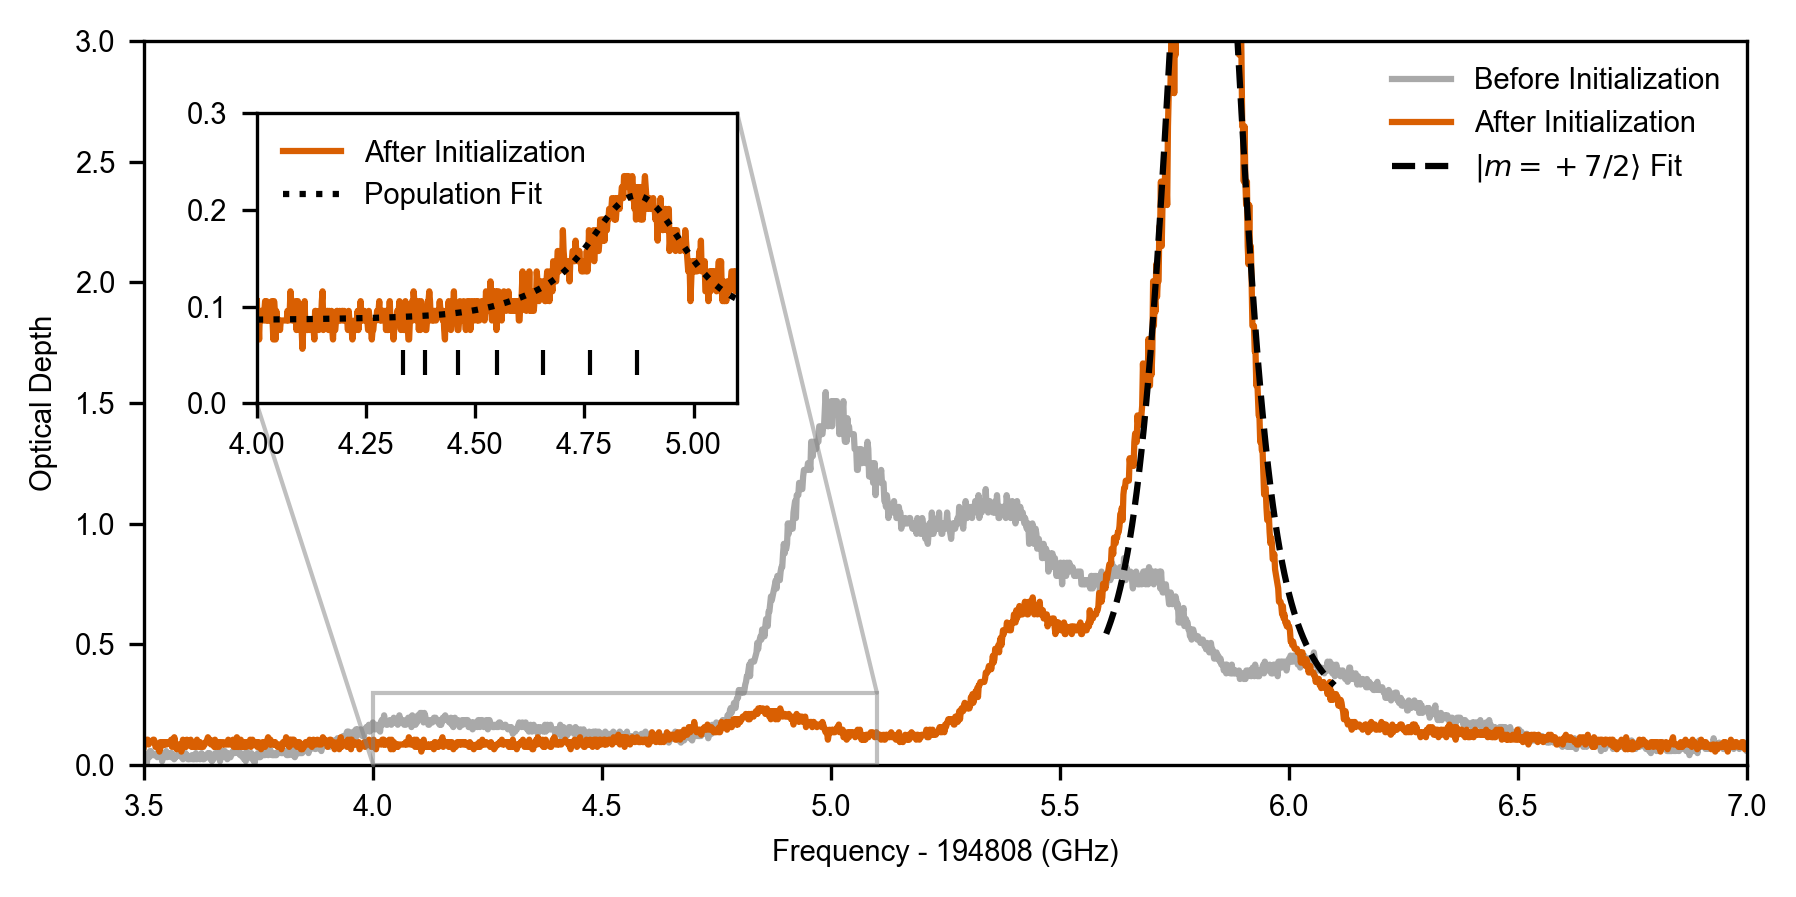

In [169]:
fig, ax_init = plt.subplots(figsize=figsize, dpi=dpi)
ax_polarize = ax_init.inset_axes([0.07, 0.5, 0.3, 0.4],
                                 xlim=xlim_inset, ylim=ylim_inset)
ax_init.indicate_inset_zoom(ax_polarize)

ax_init.plot(freq_before, od_before, color=color_memory_2,
        label='Before Initialization')
ax_init.plot(freq_init_2, od_2, color=color_memory,
        label='After Initialization')
# ax_init.plot(freq_init_2, res.eval(x=freq_init_2), ls='--', color='k',
#         label='Fit')
ax_init.plot(freq_init_2[idx_to_fit], res.best_fit, ls='--', color='k',
             label=r'$|m=+7/2\rangle$ Fit')

ax_init.set_xlim(3.5, 7)
# ax_init.set_xlim(5.5, 6)
ax_init.set_ylim(0, 3)
ax_init.set_xlabel(f"Frequency - {ref_freq} (GHz)")
ax_init.set_ylabel("Optical Depth")
ax_init.legend(framealpha=0, loc='upper right')

ax_polarize.plot(freq_init_2[idx_to_fit_polarize], od_2[idx_to_fit_polarize],
                 color=color_memory, label='After Initialization')
ax_polarize.plot(freq_init_2[idx_to_fit_polarize], res_polarize.best_fit, ls=':', color='k',
                 label='Population Fit')
transition_heights = res_polarize.params['c'].value / 2
ax_polarize.plot(center_freqs, transition_heights*np.ones_like(center_freqs), ls='', marker='|', color='k')

ax_polarize.set_xlim(xlim_inset)
ax_polarize.set_ylim(ylim_inset)
ax_polarize.legend(framealpha=0)

fig.tight_layout()

In [170]:
fig.savefig('sup_initialization_bulk.pdf')